In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# 1. 普通函数/导数

## 1. 简单的例子

In [2]:
def f(x):
    return 3*x**2-4*x+5

In [3]:
f(3)

20

In [4]:
xs = np.arange(-5,5,0.25)
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [5]:
ys = f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

关于为什么这里 一个接受标量的f(x)可以自动完成向量数组的计算，本质是因为：

NumPy 的 `ndarray` 对象对 Python 的`基本数学运算符（如 +, -, *, /, ** 等）进行了重载`。当你把这些运算符用于 NumPy 数组时，NumPy 不会像处理普通 Python 列表那样报错，而是会自动将这些操作应用到数组的每一个元素上。

在你的函数中，`x**2` 会被自动转换为对数组 x 中的每一个元素求平方。


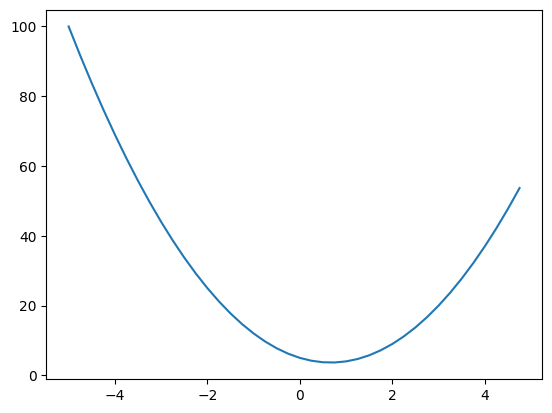

In [6]:
plt.plot(xs,ys)

不能使用微积分里求导的符号化表示，考虑用原始的数值计算

https://en.wikipedia.org/wiki/Derivative

In [7]:
h = 0.001  
x = 3.0
f(x+h)

20.014003000000002

In [8]:
(f(x+h) - f(x))/h  # 函数朝着自变量正向变化的幅度 /该方向的变化量进行归一化处理

14.00300000000243

这种计算得到的只是近似的梯度/斜率值

In [9]:
for level in range(2,18):
    h = 10**(-1*level)
    print(f"level = {h}, slope = {(f(x+h) - f(x))/h}")
print(f"true slope is {6*x-4}")

level = 0.01, slope = 14.029999999999632
level = 0.001, slope = 14.00300000000243
level = 0.0001, slope = 14.000300000063248
level = 1e-05, slope = 14.00003000000538
level = 1e-06, slope = 14.000003002223593
level = 1e-07, slope = 14.000000305713911
level = 1e-08, slope = 14.00000009255109
level = 1e-09, slope = 14.000001158365194
level = 1e-10, slope = 14.000001158365194
level = 1e-11, slope = 14.000178794049134
level = 1e-12, slope = 14.001244608152774
level = 1e-13, slope = 13.997691894473974
level = 1e-14, slope = 14.210854715202004
level = 1e-15, slope = 10.658141036401503
level = 1e-16, slope = 0.0
level = 1e-17, slope = 0.0
true slope is 14.0


可以看到：
+ 如果添加过多的0，即：趋近浮点数表示的边界，则会因为使用的是浮点数表示，而数据的表示在计算机内存中是有限的
+ 超过这个限制就会引发一定的问题
+ 所以这里在 1e-16的时候就出现计算错误了（甚至可能在更早的 1e-13的时候计算就已经失真了~）
+ 这还是建立在我的电脑默认是 float64的情况下，[CS336——2. PyTorch, resource accounting](https://blog.csdn.net/Castlehe/article/details/155040073)
    + 所以计算结果(中间计算步骤中)一定是超出了 `float64` 的表示范围了

In [10]:
print(type(h))
import sys

# 查看当前系统 float 的详细信息
print(sys.float_info)
# # mant_dig=53 表示尾数有 53 位二进制，加上 1 位隐含位，正好是 64 位 (float64) 的标准

<class 'float'>
sys.float_info(max=1.7976931348623157e+308, max_exp=1024, max_10_exp=308, min=2.2250738585072014e-308, min_exp=-1021, min_10_exp=-307, dig=15, mant_dig=53, epsilon=2.220446049250313e-16, radix=2, rounds=1)


In [11]:
h = 0.01
x = -3
print((f(x+h) - f(x))/h)  # 函数朝着自变量正向变化的幅度 /该方向的变化量进行归一化处理
print(f"true slope is {6*x-4}")

-21.9699999999996
true slope is -22


In [12]:
h = 0.01
x = 2/3
print((f(x+h) - f(x))/h)  # 函数朝着自变量正向变化的幅度 /该方向的变化量进行归一化处理
print(f"true slope is {6*x-4}")  

0.02999999999997449
true slope is 0.0


斜率有正，有负，也有零

## 2. 稍微复杂点的例子

In [13]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [14]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a+=h
d2 = a*b + c
print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h) # d这个函数对于a的导数就是b，即：-3； b同理，c导数为1

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [15]:
d1 = a*b + c
b+=h
d2 = a*b + c
print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h) 

d1 3.999699999999999
d2 3.99990001
slope 2.0001000000124947


In [16]:
d1 = a*b + c
c+=h
d2 = a*b + c
print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)  # 函数值（d）增加的量，刚好等于给c增加的量，即：d对于c的斜率为1， d = c，y=x是条斜线~，斜率为1

d1 3.99990001
d2 4.00000001
slope 0.9999999999976694


# 2. 复杂的多层函数

## 1. 标量计算图（前向传播）构建

一般需要先定义一下数据结构

In [17]:
class Value:
    def __init__(self, data):
        self.data = data
    def __repr__(self):
        """
            当你执行以下操作时，Python 会自动调用对象的 __repr__ 方法：
            1. 调用内置函数 repr(obj)。
            2. 在交互式 Python 解释器（REPL）中直接输入变量名并回车。
            3. 当对象被包含在容器（如列表 list、字典 dict、元组 tuple）中并被打印时（这是最容易踩坑的地方，容器会强制调用内部元素的 __repr__ 而不是 __str__）。
        开发者 (用于调试、日志)
            如果没有定义 __repr__，会显示默认内存地址（如 <__main__.MyClass object at 0x...>）
        """
        return f"Value(data={self.data})"

a = Value(2.0)
a

Value(data=2.0)

### U1-加减乘除重载
**✅Update 1: 除了可以表示数据，还需要这个数据有能够在其上执行的操作**，比如：加减乘除

In [18]:
class Value:
    def __init__(self, data):
        self.data = data
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        """
        运算符重载”（Operator Overloading)
        在 Python 中，运算符重载是通过定义类中的特殊方法（魔术方法 / Dunder Methods） 来实现的。__add__ 方法专门用于重载加法运算符 +。
        """
        out = Value(self.data + other.data)
        return out
    def __mul__(self,other):
        """
        运算符重载”（Operator Overloading)
        在 Python 中，运算符重载是通过定义类中的特殊方法（魔术方法 / Dunder Methods） 来实现的。__add__ 方法专门用于重载加法运算符 +。
        """
        out = Value(self.data * other.data)
        return out

In [19]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)

print(a*b + c) # 自动调用，内部执行的具体过程就下面这个
print((a.__mul__(b)).__add__(c))

Value(data=4.0)
Value(data=4.0)


可以看到，现在已经和之前直接浮点数运算结果一样了。。。

### U2-记录值是哪两个值二元操作的结果
**✅Update 2: 数据结构+操作定义好之后，为了保证能够复现/保留计算图（即：计算顺序）**，
+ 需要维护哪些值生成了其他值的指针（即a→b，则b就是a的子节点）
+ 其实就是`记录当前值的直接来自于哪些值`

这个时候，其实就已经很接近：<https://github.com/karpathy/micrograd/blob/master/micrograd/engine.py> 这里的完整实现了

In [20]:
class Value:
    def __init__(self, data, _children = ()):
        """
        为了表示子节点，引入_children，默认情况是空的元组
        """
        self.data = data
        self._prev = set(_children)  # 这里为了效率，直接把前置集合设置成set(_children) 
        # 注意，这里的children和prev[ious] ，
        # 前者应该是从函数构成角度来讲，其余都是因变量的自变量；
        # 后者是从计算图的流通顺序来说，自变量都是因变量之前的节点
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        out = Value(self.data + other.data, (self, other)) # 当执行操作时，就需要记录操作顺序（把操作节点传进去）
        return out
    def __mul__(self,other):
        out = Value(self.data * other.data, (self, other))
        return out

In [21]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
d = a*b + c
d

Value(data=4.0)

In [22]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

### U3-记录值来自什么操作
**✅Update 3: 现在有了每个计算节点的值，还需要知道是哪个操作生成了这个值**

In [23]:
class Value:
    def __init__(self, data, _children = (), _op=''):
        """
        为了表示操作，这里也定义一个op字符串来表示操作，对于单个Value来说，它的来源一定是被分解成基本运算的一步，所以操作只会是单个字符串
        """
        self.data = data
        self._prev = set(_children)  
        self._op = _op
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        out = Value(self.data + other.data, (self, other), '+') # 当执行操作时，就需要记录操作顺序（把操作节点传进去）
        return out
    def __mul__(self,other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

In [24]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
d = a*b + c
print(d)
d._prev, d._op

Value(data=4.0)


({Value(data=-6.0), Value(data=10.0)}, '+')

帮助进行计算图的可视化代码：

In [25]:
!pip install graphviz


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [26]:
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        # dot.node(name=str(id(n)), label = "{ data %.4f | grad %.4f }" % (n.data, n.grad), shape='record')
        dot.node(name=str(id(n)), label = "{ data %.4f}" % (n.data), shape='record')
        # 创造了 * + 这样的伪节点，以及对应的连接
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

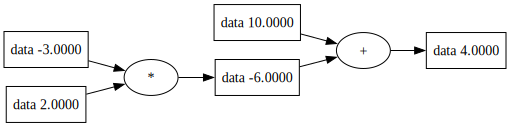

In [27]:
draw_dot(d)

### U4-加个标签（变量名）
**✅Update 4: 给每个数据再加个标签，这样看起来会更容易**

In [28]:
class Value:
    def __init__(self, data, _children = (), _op='', label=''):
        """
        这个label其实就是给每个Value对象起个名字
        """
        self.data = data
        self._prev = set(_children)  
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        out = Value(self.data + other.data, (self, other), '+') # 当执行操作时，就需要记录操作顺序（把操作节点传进去）
        return out
    def __mul__(self,other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

In [29]:
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s|data %.4f}" % (n.label, n.data), shape='record')
        # 创造了 * + 这样的伪节点，以及对应的连接
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

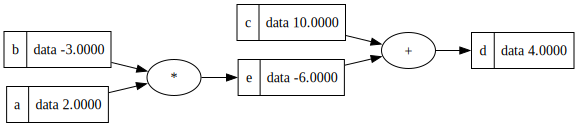

In [30]:
a = Value(2.0,label='a')  
b = Value(-3.0,label='b')
c = Value(10.0,label='c')
e = a*b
e.label = 'e'
d = e + c
d.label = 'd'
draw_dot(d)

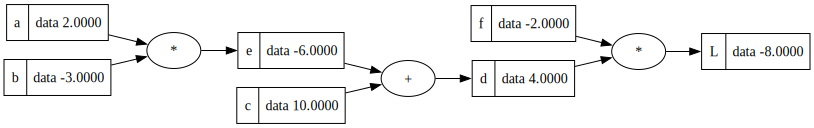

In [31]:
# 也可以更复杂一点

a = Value(2.0,label='a')  
b = Value(-3.0,label='b')
c = Value(10.0,label='c')
e = a*b
e.label = 'e'
d = e + c
d.label = 'd'
f = Value(-2, label='f')
L = d*f
L.label='L'
draw_dot(L)

这就是标量前向传播的可视化过程，前向就是计算所有操作的值，最后得到结果值

In [35]:
def f(x):
    return Value(3,label='w1')*x+Value(5,label='w2')

In [38]:
L = f(Value(4, label = 'x1'))

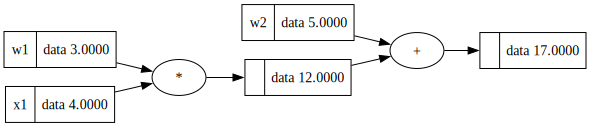

In [39]:
draw_dot(L)

如果换成这种包含自变量的正儿八经的函数表示，可以看到，这些节点里，就包括数据节点，权重节点了~

注意，这里的区别在于，正常情况下，
```python
def f(x):
    return Value(3)*x*Value(2)+Value(4)*x+Value(5)
```

上式中，一般 `x`和`f(x)`是已知的， `w1`, `w2`这种才是未知的，这个例子举的不太好,所以`w1`和`w2`是需要确定的权重
+ 所以关注的是最后的输出对于中间某些叶节点（权重节点，即神经网络的权重）的导数，这些权重会根据梯度信息进行更新
+ 而最后的输出对于其他叶节点（即：数据本身）的导数，则不需要考虑，因为单条数据不会发生改变，是固定的

## 2. 标量反向传播

### U5-记录导数
*Update 5: 在Value中添加一个变量，用来保存损失函数L对该值的导数**

In [2]:
class Value:
    def __init__(self, data, _children = (), _op='', label=''):
        """
        这个label其实就是给每个Value对象起个名字
        """
        self.data = data
        self.grad = 0   # 初始梯度都设置为0， 梯度=0表示没有影响~
        self._prev = set(_children)  
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        out = Value(self.data + other.data, (self, other), '+') # 当执行操作时，就需要记录操作顺序（把操作节点传进去）
        return out
    def __mul__(self,other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

In [1]:
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s|data %.4f|grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        # 创造了 * + 这样的伪节点，以及对应的连接
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

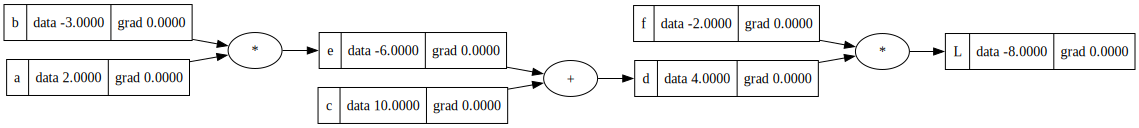

In [43]:
a = Value(2.0,label='a')  
b = Value(-3.0,label='b')
c = Value(10.0,label='c')
e = a*b
e.label = 'e'
d = e + c
d.label = 'd'
f = Value(-2, label='f')
L = d*f
L.label='L'
draw_dot(L)

接下来进行反向传播，需要从L损失函数开始逐个计算对每个节点的导数，很明显， L对L的导数就是1

完整计算式子是： L = (a*b+c)*f

In [60]:
def lol():
    """
    临时计算每个变量的导数
    """
    # 计算a的，就给a的数值加上h
    h = 0.0001
    
    a = Value(2.0,label='a')  
    b = Value(-3.0,label='b')
    c = Value(10.0,label='c')
    e = a*b
    e.label = 'e'
    d = e + c
    d.label = 'd'
    f = Value(-2, label='f')
    L = d*f
    L.label='L'
    L1 = L.data

    a = Value(2.0,label='a')  
    b = Value(-3.0 + h,label='b')
    c = Value(10.0,label='c')
    e = a*b
    e.label = 'e'
    d = e + c
    d.label = 'd'
    f = Value(-2, label='f')
    L = d*f
    L.label='L'
    L2 = L.data

    print((L2-L1)/h)
lol()

-4.000000000008441


使用上面的函数，手动计算损失函数L对每个节点的导数

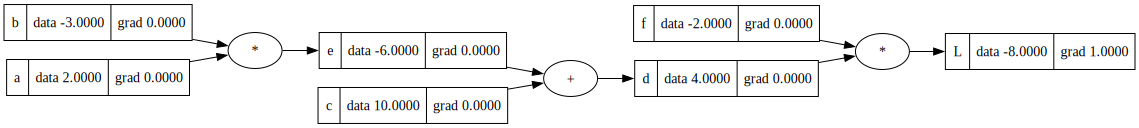

In [50]:
L.grad = 1.0
draw_dot(L)

然后先看 L对f和d的导数，很明显，dL/df = d; dL/dd = f

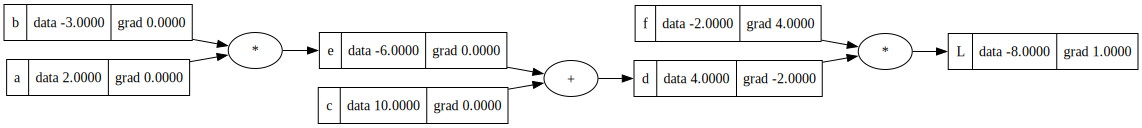

In [51]:
f.grad = 4
d.grad = -2  # 这个导数可以用 lol函数再验证一下,这个验证过程，就类似于一种内联的梯度检验
draw_dot(L)

内联的梯度检验(inline gradient check)
+ 通过反向传播等方式计算中间所有过程的导数，并最终计算出梯度后，进行的一种验证过程
+ 数值梯度(numerical gradient): 通过使用微小步长来估计梯度

接下来，计算  L 对e和c的梯度，

dL/dd = -2， 
 
dd/de = 1 根据 (f(x+h)-f(x))/h →  (e+h+c -(e+c))/h = h/h = 1

dd/dc = 1 

dL/de = (dL/dd)*(dd/de) = -2, dL/dc同理。→  所以可以认为，**加法节点只是简单的将反向传播过程的上一个数据节点的梯度复制**

根据 <https://en.wikipedia.org/wiki/Chain_rule>, 

至此，其实就可以知道，
1. 进行加法操作的两个节点（比如 e和c），`局部梯度都是1`,而这两个节点的`全局梯度`，是`加法的结果变量`的梯度，即：只是一个梯度的分配器；
2. 进行乘法操作的两个节点，局部梯度是进行操作的另一个对象的值，全局梯度就是局部乘以 乘法操作结果变量的梯度

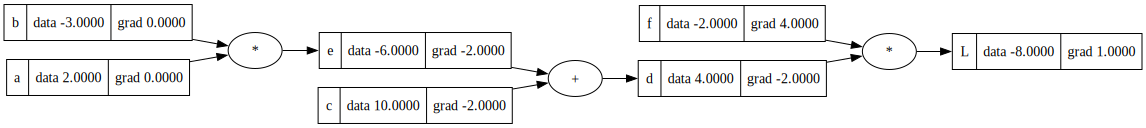

In [57]:
c.grad = d.grad
e.grad = d.grad  # 这个导数可以用 lol函数再验证一下,这个验证过程，就类似于一种内联的梯度检验
draw_dot(L)

继续计算 

dL/da = (dL/de)*(de/da)=(dL/de)*b   

e = a*b

de/da = ((a+h)\*b - a*b)/h = b

dL/db 同理，由此可以看出，**乘法节点就是交换两个操作数的值作为梯度**

同样，也可以用 lol 函数来进行数值梯度的计算，来进行验证

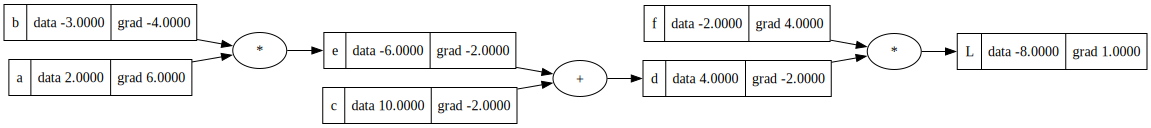

In [58]:
a.grad = e.grad*b.data
b.grad = e.grad*a.data
draw_dot(L)

通过调整输入，来影响 L

In [65]:
a = Value(2.0,label='a')  
b = Value(-3.0,label='b')
c = Value(10.0,label='c')

# a.data +=0.01*a.grad
b.data +=0.01*b.grad
# c.data +=0.01*c.grad
# f.data +=0.01*f.grad

e = a*b; e.label = 'e'
d = e+c; d.label = 'd'
L = d*f
print(L)

Value(data=-7.84)


> 可以看到:<br/>
> L的数值从 -8增加到了 -7.2，<br/>
> dL/db = -4, 说明随着b增大，L会减小；所以**对于b来说，沿着梯度方向**，b其实是在减小→ **L增加** <br/>
> 上述四个变量，不管单独改变哪个，只要是沿着梯度方向，都是 L增加的方向<br/>
> 数学说明详见： [梯度变化的数学解释](https://blog.csdn.net/Castlehe/article/details/161984038)

自变量朝着梯度方向变化，因变量就会增大；

根据这点，就可以来通过梯度控制自变量（即神经网络的权重），进而影响因变量（即损失函数），实现对神经网络的参数更新/训练

# 3. 更复杂的例子（多层感知机）

直接搜索 cs231n neuron

<img src="https://cs231n.github.io/assets/nn1/neuron_model.jpeg" width=40%>

<img src="https://cs231n.github.io/assets/nn1/neural_net2.jpeg" width=40%>

这里会以tanh为例，作为激活函数

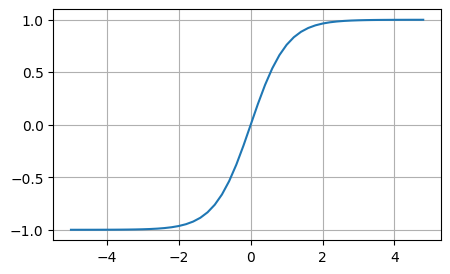

In [7]:
import numpy as np
import matplotlib.pyplot as plt
x = np.arange(-5,5,0.2)
y = np.tanh(x)
plt.figure(figsize=(5,3))
plt.plot(x,y);plt.grid()

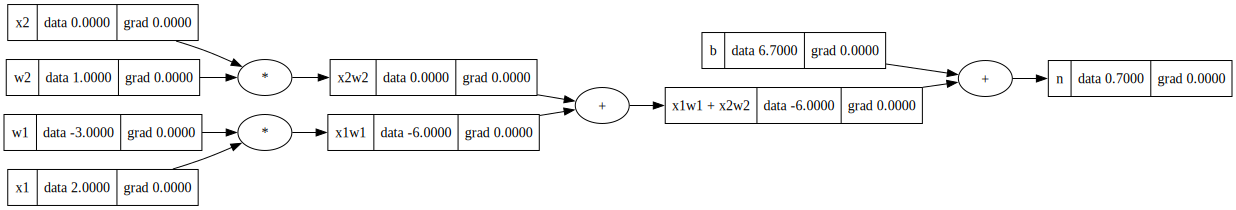

In [3]:
# 一个二维神经元 ，一个神经元，接受的输入是 1x2d的

# inputs，固定数值，不会变，没必要对这个数求梯度，
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

# weights，需要变化的，会依据这个的梯度来影响最终的n，需要求梯度
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias 偏置项
b = Value(6.7, label = 'b')

# 前向计算过程，把整个过程拆解成原子操作，就可以为所有的中间节点建立引用关系，在此基础上求解所有的梯度了
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
draw_dot(n)

上述还没有加入tanh激活函数，需要在 Value 中实现相关操作

## U6- 添加tanh实现

https://en.wikipedia.org/wiki/Hyperbolic_functions#Tanh

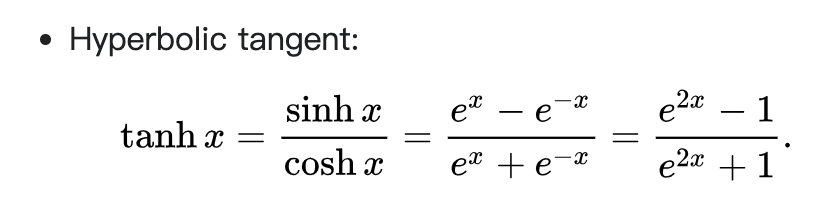


在Value的操作实现中，并不是一定要实现最基础的原子级运算单元，可以在任意抽象层次创建函数。比如：

对于tanh，可以创建指数函数，再去用加法和乘法构建tanh的公式；也可以直接创建tanh这个函数实现。

只要你知道，怎么对这个操作求导（获取局部导数）即可，类似上面的加法和乘法~

In [2]:
import math
class Value:
    def __init__(self, data, _children = (), _op='', label=''):
        self.data = data
        self.grad = 0  
        self._prev = set(_children)  
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        out = Value(self.data + other.data, (self, other), '+') 
        return out
    def __mul__(self,other):
        out = Value(self.data * other.data, (self, other), '*')
        return out
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self,), 'tanh')
        return out

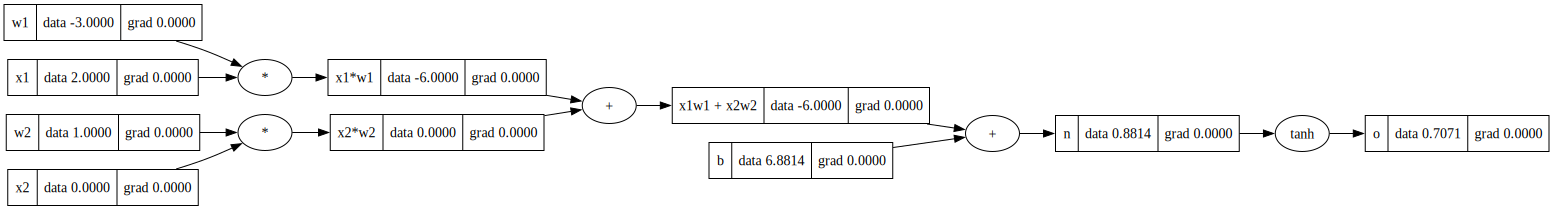

In [7]:
from a_utils import draw_dot
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813735870195432, label = 'b')
# 这里b设置这个奇怪的值，是为了保证后续反向传播的时候，出现的值会比较规整，不会有奇奇怪怪的值
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
# x1w1x2w2 = x1*w1 + x2*w2; # 注意，这里不能再用乘法来表示，必须用上面定义过的变量来表示，不然
# 在类似 micrograd 的库中，x1 * w1 每次都会创建一个全新的对象。如果你在设置 label 之后，又不小心重新执行了乘法，新对象会覆盖旧对象，label 就丢失了。
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'
draw_dot(o)

当 `b = Value(6.7, label = 'b')`时

可以看到， o的值和n的值差不多，`o.data = 0.6044`, `n.data = 0.7`, 即：tanh发挥的压缩效果不明显，这是因为输入（n）的值比较小，可以看看 上面tanh的图

当 `b = Value(8, label = 'b')`时

n的值就是 2.0， 即tanh的输入变大了，此时 o.data = 0.964，这时候压缩率就达到了1倍，同时此时，已经到达了tanh函数的尾部，n的值再大，o的值也只会趋于1

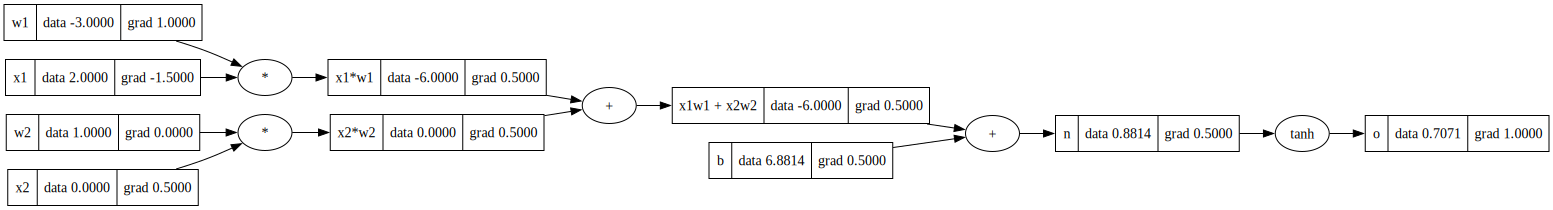

In [8]:
o.grad = 1.0

n.grad = 1 - o.data**2
b.grad = 1 - o.data**2

x1w1x2w2.grad = 1 - o.data**2

x1w1.grad = 1 - o.data**2
x2w2.grad = 1 - o.data**2

w1.grad = x1.data * x1w1.grad
x1.grad = w1.data * x1w1.grad
w2.grad = x2.data * x2w2.grad
x2.grad = w2.data * x2w2.grad

draw_dot(o)

上图中每个变量的grad，即全局梯度，反应的是这个变量调整会如何影响最终的结果，而不是下一步的结果
+ 以 w2 为例，由于会与x2相乘，而x2 = 0， 因此不管 w2如何变化，对最终的结果 o都不会有影响
+ 就好像计算一个公式，0项总是会被直接pass一样

对于上面这个例子；
+ 可以改变的权重只有 w1和w2， 而w2.grad = 0, 无影响
+ 因此能起作用的只有 w1, 即 w1 += 0.01*w1.grad → o就会增大

**do/dn**
o = tanh(n)

do/dh = 1 -tanh(n)**2 # wiki 页面下拉就有  https://en.wikipedia.org/wiki/Hyperbolic_functions#Derivatives

又有 o = tanh(h)

→ do/dh = 1-o**2

**do/db and do/dx1w1x2w2**

do/db = do/dn * dn/db = do/dn 
dn/db = ((b+h + x1w1+x2w2) - (b + x1w1+x2w2))/h = 1

**dx1w1x2w2/dx1w1 and dx1w1x2w2/dx2w2**

同理，加法节点对应的二元数的局部梯度是1，全局梯度是传递加法结果变量的梯度


# 4. 自动反向梯度计算

## u7-添加自动反向梯度实现

In [ ]:
import math
class Value:
    def __init__(self, data, _children = (), _op='', label=''):
        self.data = data
        self.grad = 0  
        self._backward = lambda:None  # 这里是个函数，默认是空，什么都不做，对于叶节点来说，确实是什么都不做
        # 存储对于一个计算op节点(比如，乘法加法操作)，在反向传播过程中将输出梯度链式传递到输入梯度的逻辑 
        self._prev = set(_children)  
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"
        
    def __add__(self,other):
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            """这里定义调用 out.grad 时需要执行的操作
            对于加法操作，out = self.data + other.data
            所以这里的目标就是 把 out.grad 传给 self.grad 和 other.grad
            dout/dself=1, 即self.grad 和 other.grad的局部梯度是1， 
            全局梯度就取决于out.grad（即最终表达式对于out的梯度）
            """
            self.grad = 1.0*out.grad
            other.grad = self.grad
        out._backward = _backward  
        # out也是Value类型，相当于对out的 self._backward进行赋值
        # 这个不会自动执行，而是需要我们执行完加法操作后手动调用来完成梯度传播
        return out
        
    def __mul__(self,other):
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad
        out._backward =  _backward   # 和add操作里的一样
        return out
        
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        # 这里其实就是 t = tanh(x) 即 dt/dx = 1-x**2
        # 注意，实际使用的时候不一定tanh是最后一步，因此，这里不能直接乘以1，而依然需要用 Out.grad来承接反向传播上一步的梯度
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad = (1 - t**2)*out.grad
        out._backward = _backward
        return out